In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.tsa.stattools as ts

In [4]:
data=yf.download(['NVDA','AMD'],start='2020-01-01',end='2024-01-01')
prices = data['Close']
print(prices.head())

[*********************100%***********************]  2 of 2 completed

Ticker            AMD      NVDA
Date                           
2020-01-02  49.099998  5.963804
2020-01-03  48.599998  5.868346
2020-01-06  48.389999  5.892956
2020-01-07  48.250000  5.964301
2020-01-08  47.830002  5.975488


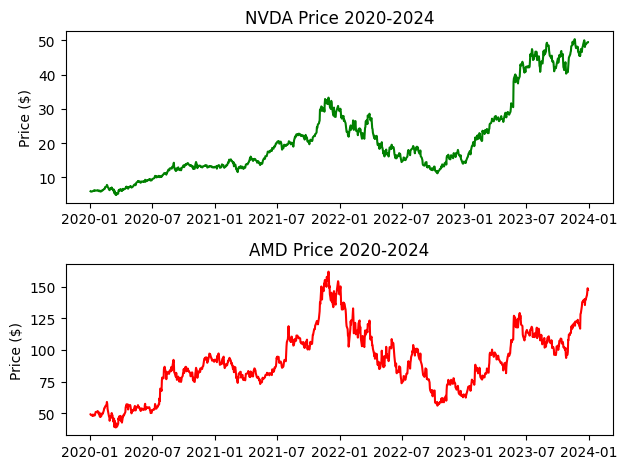

In [6]:
fig, axes = plt.subplots(2, 1)

axes[0].plot(prices['NVDA'], color='green')
axes[0].set_title("NVDA Price 2020-2024")
axes[0].set_ylabel('Price ($)')

axes[1].plot(prices['AMD'], color='red')
axes[1].set_title("AMD Price 2020-2024")
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()


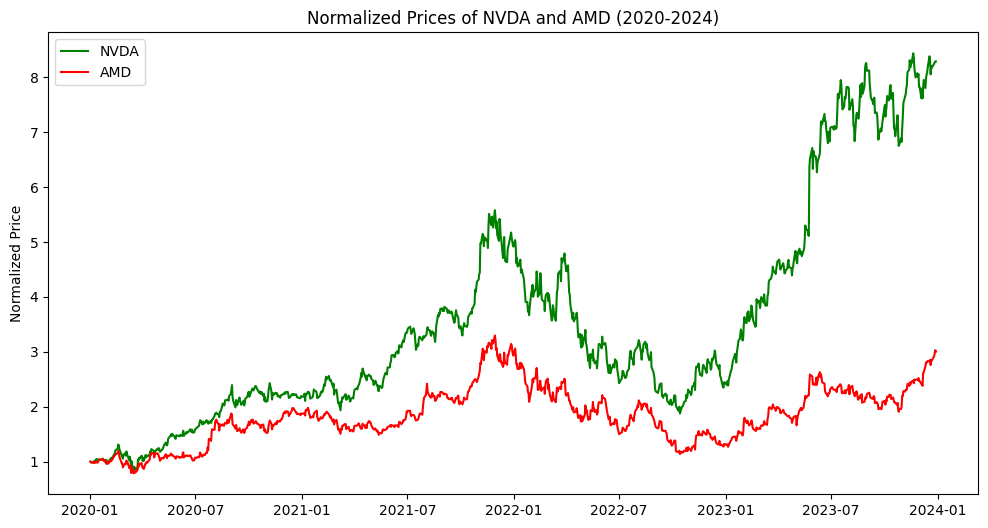

In [ ]:
normalized_prices = prices / prices.iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(normalized_prices['NVDA'], label='NVDA', color='green')
plt.plot(normalized_prices['AMD'], label='AMD', color='red')
plt.title("Normalized Prices of NVDA and AMD (2020-2024)")
plt.ylabel('Normalized Price')
plt.legend()
plt.show()

Engle-Granger cointegration test to determine whether the spread between the two series is stationary. A p-value below 0.05 indicates statistically significant cointegration.

In [8]:
from statsmodels.tsa.stattools import coint
pvalue = coint(prices['NVDA'], prices['AMD'])[1]
print(f"Cointegration p-value: {pvalue:.4f}")


Cointegration p-value: 0.8106


The full period result (0.8106) is heavily influenced by NVDA's outsized growth post-2023. 
We retest on the pre-AI boom period (2020-2023) to see if the relationship was stronger 
before NVDA fundamentally diverged from AMD.

In [17]:
#Pre Ai Boom
data2 = yf.download(['NVDA','AMD'],start='2020-01-01',end='2023-01-01')
prices2 = data2['Close']
pvalue2 = coint(prices2['NVDA'], prices2['AMD'])[1]
print(f"Cointegration p-value (2020-2023): {pvalue2:.4f}")


[*********************100%***********************]  2 of 2 completed

Cointegration p-value (2020-2023): 0.1077


Before the AI boom (2020-2023), NVDA and AMD showed closer cointegration (p-value: 0.1077) 
compared to the full period including the AI boom (p-value: 0.81). However, neither window 
passes the 0.05 significance threshold, suggesting the pair is not reliably tradeable 
under a strict cointegration framework.

[*********************100%***********************]  2 of 2 completed


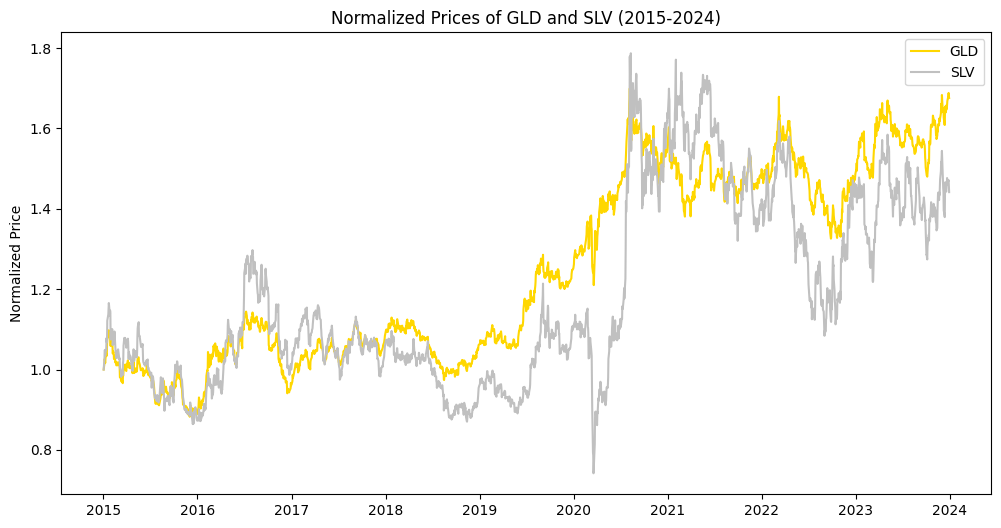

In [15]:
data_metals = yf.download(['GLD','SLV'],start='2015-01-01',end='2024-01-01')
prices_metals = data_metals['Close']

normalized_metal_prices = prices_metals / prices_metals.iloc[0]
plt.figure(figsize=(12, 6))
plt.plot(normalized_metal_prices['GLD'], label='GLD', color='gold')
plt.plot(normalized_metal_prices['SLV'], label='SLV', color='silver')
plt.title("Normalized Prices of GLD and SLV (2015-2024)")
plt.ylabel('Normalized Price')
plt.legend()
plt.show()


GLD and SLV (gold and silver ETFs) were tested as a second candidate pair given their 
strong fundamental relationship as precious metals.
Despite clear visual correlation, the cointegration test returned a p-value of 0.4135, 
well above the 0.05 threshold. This means we cannot confirm that the spread between 
GLD and SLV is stationary or mean-reverting over this period. The 2020 COVID crash 
likely played a significant role. SLV sold off sharply while GLD held its value as a 
safe haven asset, disrupting the relationship between the two series.

In [19]:
pvalue_metals = coint(prices_metals['GLD'], prices_metals['SLV'])[1]
print(f"Cointegration p-value for GLD and SLV (2015-2024): {pvalue_metals:.4f}")

Cointegration p-value for GLD and SLV (2015-2024): 0.4135


To isolate the impact of COVID, GLD and SLV were retested over the pre-COVID period 
(2015-2020). This produced a p-value of 0.9687 (actually much higher than the first test).

My reason for this is that the spread between them needs to actively bounce around a stable average (mean-revert). 
Pre-COVID, GLD and SLV drifted slowly sideways together with very little spread movement, which 
the test does not reward. The COVID period, despite being a disruption, introduced more 
spread variation and ironically made the full period result slightly better.

In [18]:
#Pre Covid Metals
data_metals_pre_covid = yf.download(['GLD','SLV'],start='2015-01-01',end='2020-01-01')
prices_metals_pre_covid = data_metals_pre_covid['Close']
pvalue_metals_pre_covid = coint(prices_metals_pre_covid['GLD'], prices_metals_pre_covid['SLV'])[1]
print(f"Cointegration p-value for GLD and SLV (2015-2020): {pvalue_metals_pre_covid:.4f}")


[*********************100%***********************]  2 of 2 completed

Cointegration p-value for GLD and SLV (2015-2020): 0.9687


In [27]:
data_oil=yf.download(['XOM','CVX'],start='2015-01-01',end='2020-01-01')
prices_oil = data_oil['Close']
pvalue_oil = coint(prices_oil['XOM'], prices_oil['CVX'])[1]
print(f"Cointegration p-value for XOM and CVX (2015-2020): {pvalue_oil:.4f}")

[*********************100%***********************]  2 of 2 completed

Cointegration p-value for XOM and CVX (2015-2020): 0.0411


In [28]:
data_oil_full=yf.download(['XOM','CVX'],start='2015-01-01',end='2024-01-01')
prices_oil_full = data_oil_full['Close']
pvalue_oil_full = coint(prices_oil_full['XOM'], prices_oil_full['CVX'])[1]
print(f"Cointegration p-value for XOM and CVX (2015-2024): {pvalue_oil_full:.4f}")

[*********************100%***********************]  2 of 2 completed

Cointegration p-value for XOM and CVX (2015-2024): 0.6916


In [30]:
import statsmodels.api as sm
X = sm.add_constant(prices_oil['XOM'])
model = sm.OLS(prices_oil['CVX'], X).fit()
hedge_ratio = model.params['XOM']
print(f"Hedge Ratio (XOM to CVX): {hedge_ratio:.4f}")


Hedge Ratio (XOM to CVX): 1.6581


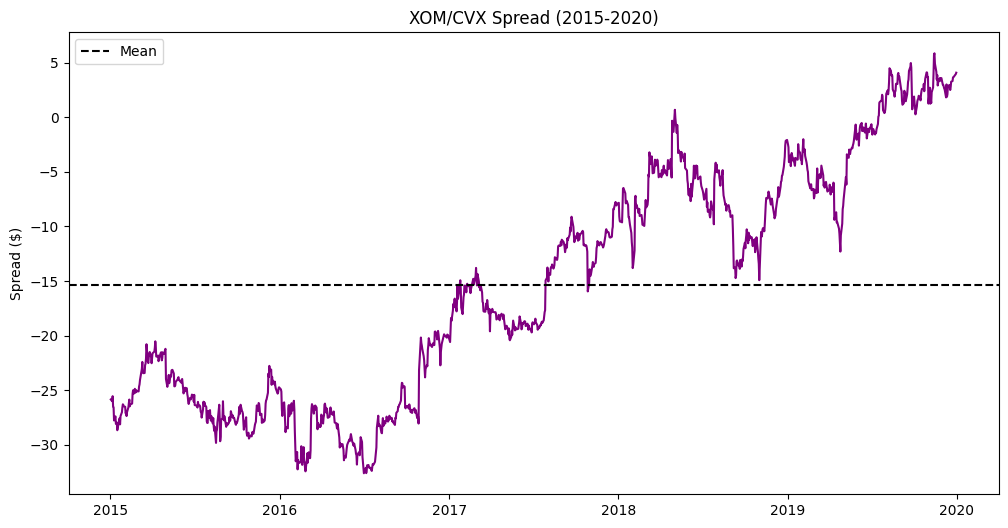

In [31]:
spread = prices_oil['CVX'] - hedge_ratio * prices_oil['XOM']

plt.figure(figsize=(12, 6))
plt.plot(spread, color='purple')
plt.axhline(spread.mean(), color='black', linestyle='--', label='Mean')
plt.title("XOM/CVX Spread (2015-2020)")
plt.ylabel('Spread ($)')
plt.legend()
plt.show()


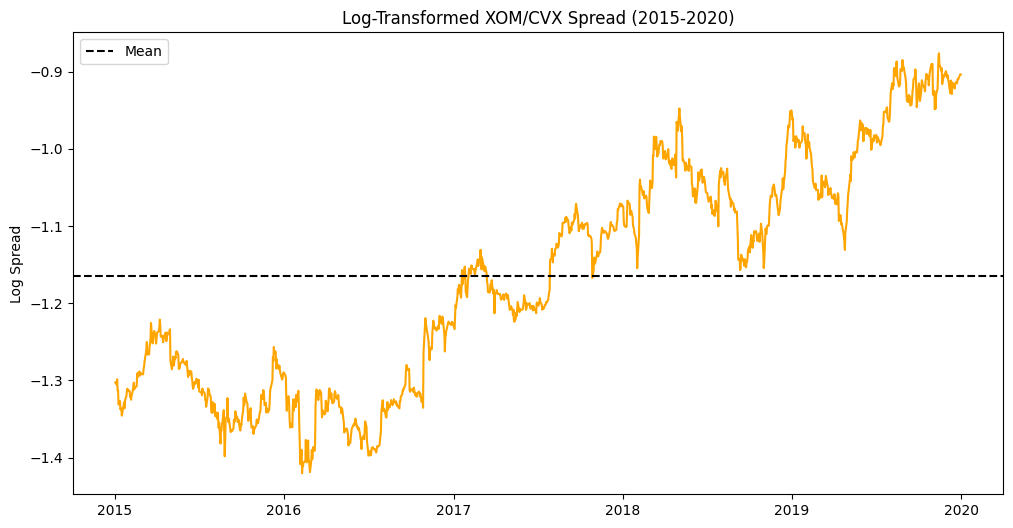

In [32]:
import numpy as np

log_oil_prices = np.log(prices_oil)

x_log = sm.add_constant(log_oil_prices['XOM'])
model_log = sm.OLS(log_oil_prices['CVX'], x_log).fit()
hedge_ratio_log = model_log.params['XOM']

spread_log = log_oil_prices['CVX'] - hedge_ratio_log * log_oil_prices['XOM']

plt.figure(figsize=(12, 6))
plt.plot(spread_log, color='orange')
plt.axhline(spread_log.mean(), color='black', linestyle='--', label='Mean')
plt.title("Log-Transformed XOM/CVX Spread (2015-2020)")
plt.ylabel('Log Spread')
plt.legend()
plt.show()


In [33]:
data_soda = yf.download(['KO','PEP'],start='2015-01-01',end='2024-01-01')
prices_soda = data_soda['Close']
pvalue_soda = coint(prices_soda['KO'], prices_soda['PEP'])[1]
print(f"Cointegration p-value for KO and PEP (2015-2024): {pvalue_soda:.4f}")


[*********************100%***********************]  2 of 2 completed

Cointegration p-value for KO and PEP (2015-2024): 0.0095


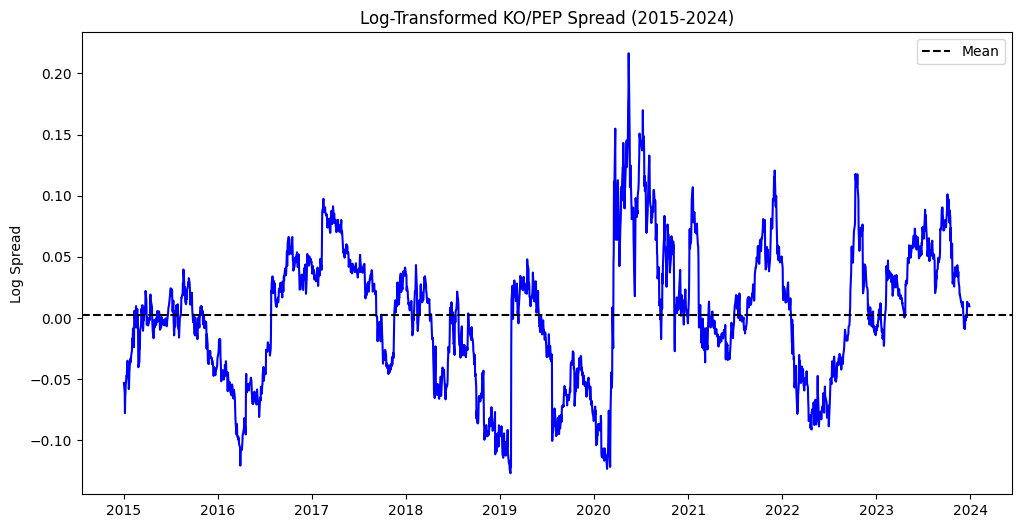

Hedge Ratio (KO to PEP): 1.2576


In [36]:
log_prices_soda = np.log(prices_soda)
x_log_soda = sm.add_constant(log_prices_soda['KO'])
model_log_soda = sm.OLS(log_prices_soda['PEP'], x_log_soda).fit()
hedge_ratio_log_soda = model_log_soda.params['KO']

spread_log_soda = log_prices_soda['PEP'] - hedge_ratio_log_soda * log_prices_soda['KO']
plt.figure(figsize=(12, 6))
plt.plot(spread_log_soda, color='blue')
plt.axhline(spread_log_soda.mean(), color='black', linestyle='--', label='Mean')
plt.title("Log-Transformed KO/PEP Spread (2015-2024)")
plt.ylabel('Log Spread')
plt.legend()
plt.show()

print(f"Hedge Ratio (KO to PEP): {hedge_ratio_log_soda:.4f}")


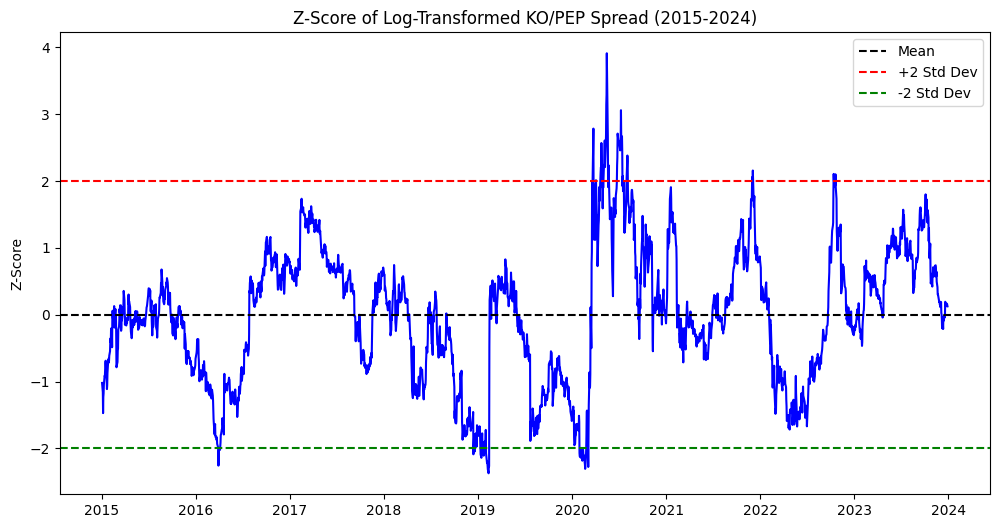

In [38]:
spread_mean = spread_log_soda.mean()
spread_std = spread_log_soda.std()
z_score = (spread_log_soda - spread_mean) / spread_std

plt.figure(figsize=(12, 6))
plt.plot(z_score, color='blue')
plt.axhline(0, color='black', linestyle='--', label='Mean')
plt.axhline(2, color='red', linestyle='--', label='+2 Std Dev')
plt.axhline(-2, color='green', linestyle='--', label='-2 Std Dev')
plt.title("Z-Score of Log-Transformed KO/PEP Spread (2015-2024)")
plt.ylabel('Z-Score')
plt.legend()
plt.show()


In [39]:
signals = pd.Series(0, index=z_score.index)

signals[z_score > 2] = -1  # Short PEP, Long KO
signals[z_score < -2] = 1  # Long PEP, Short KO

signals = signals.replace(0, np.nan).ffill().fillna(0)
signals[np.abs(z_score) < 0.5] = 0  # Exit positions when z-score is close to mean

print(signals.value_counts())


 0.0    985
 1.0    685
-1.0    594
Name: count, dtype: int64


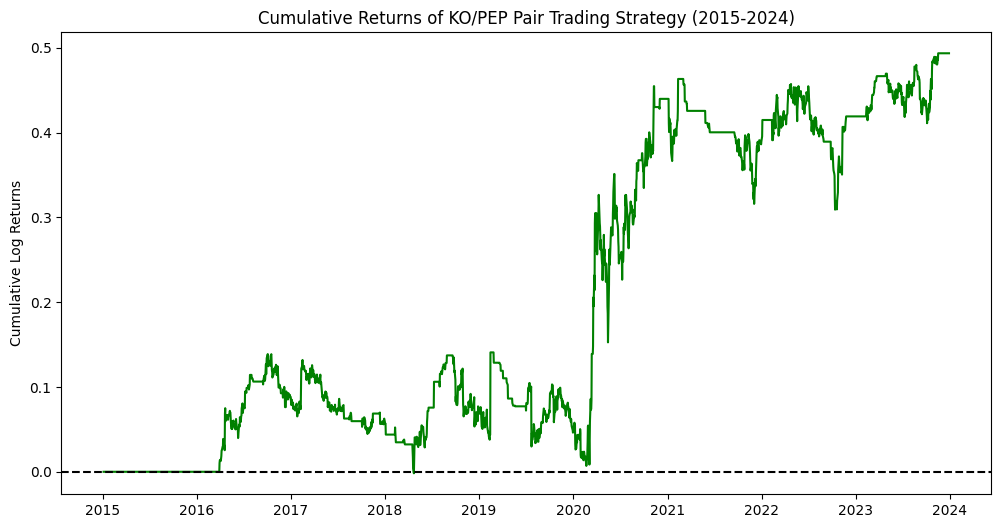

In [41]:
spread_returns = spread_log_soda.diff()

strategy_returns = signals.shift(1) * spread_returns
cumulative = strategy_returns.cumsum()

plt.figure(figsize=(12, 6))
plt.plot(cumulative, color='green')
plt.axhline(0, color='black', linestyle='--')
plt.title("Cumulative Returns of KO/PEP Pair Trading Strategy (2015-2024)")
plt.ylabel('Cumulative Log Returns')
plt.show()



In [42]:
sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252)

rolling_max = cumulative.cummax()
drawdown = cumulative - rolling_max
max_drawdown = drawdown.min()

print(f"Sharpe Ratio: {sharpe:.4f}")
print(f"Max Drawdown: {max_drawdown:.4f}")

Sharpe Ratio: 0.4371
Max Drawdown: -0.1739
